In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [26]:
from sklearn import linear_model
from sklearn.linear_model import Lasso
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

In [7]:
insurance_data = pd.read_csv(r"C:\Users\hp\Downloads\insurance.csv")

In [8]:
insurance_data

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [11]:
X = insurance_data.drop(columns=["charges", "region"])
y = insurance_data["charges"]

X = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

X = pd.get_dummies(X, columns=["region"], drop_first = True, dtype=int)


X['sex'] = X["sex"].map({"female" : 1, "male": 0})
X['smoker'] = X["smoker"].map({"yes" : 1, "no": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.15, random_state=42
)

Mean Square for alpha = 0.001: 30833050.01166897
Mean Square for alpha = 0.1: 30834178.111271407
Mean Square for alpha = 1: 30844486.637558967
Mean Square for alpha = 2: 30856058.996519558
Mean Square for alpha = 5: 30891491.741661206
Mean Square for alpha = 10: 30953157.082714625
Mean Square for alpha = 20: 31085493.309856415
Mean Square for alpha = 30: 31209139.014811408
Mean Square for alpha = 40: 31334631.489158668
Mean Square for alpha = 50: 31464742.622907534
Mean Square for alpha = 100: 31618127.634932496


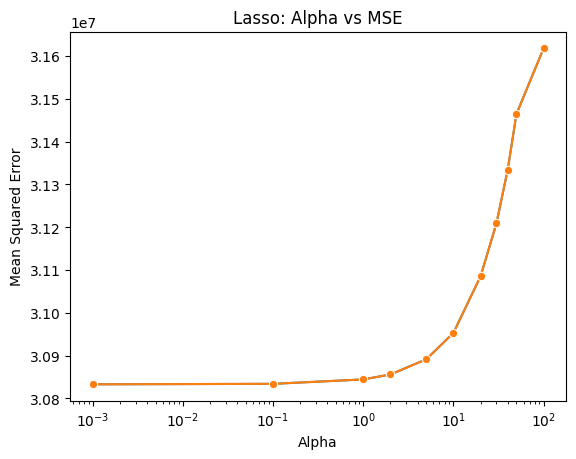

In [19]:
alphas = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
mses = []

for a in alphas:
    lasso_model = Lasso(alpha = a)
    lasso_model.fit(X_train, y_train)
    
    y_pred = lasso_model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    
    print(f"Mean Square for alpha = {a}:", mse)
    mses.append(mse)

sns.lineplot(x=alphas, y=mses, marker="o")
sns.lineplot(x=alphas, y=mses, marker="o")
plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("Mean Squared Error")
plt.title("Lasso: Alpha vs MSE")
plt.show()

# LassoCV

In [27]:
a = [0.001, 0.1, 1, 2, 5, 10, 20, 30, 40, 50, 100]
lasso_cv_model = LassoCV(
    alphas=a,    
    cv=5,
    max_iter=1000,
    random_state=42
)

lasso_cv_model.fit(X_train, y_train)

print("Best alpha:", lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(X_test)
mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("mse =", mse)
print("r2 =", r2)

Best alpha: 100.0
mse = 31618127.634932496
r2 = 0.7923517504514981


# ElasticNet